# Simple ReAct Agent with LangChain + LangGraph

This notebook implements the same toy ReAct-style agent as the hand-built Python version:

- A user asks a question.
- The model decides whether it needs a tool.
- If it calls a tool, the tool result is added back as an observation.
- The model continues until it can answer.

The original version used:

```text
Thought → Action → PAUSE → Observation → Answer
```

This version uses LangChain tool definitions and a LangGraph state machine:

```text
START → assistant → tools → assistant → END
```

The important conceptual mapping is:

| From-scratch version | LangChain / LangGraph version |
|---|---|
| `known_actions` dictionary | list of LangChain `@tool` objects |
| regex parser for `Action: ...` | model-native tool calls |
| manual `while` loop | LangGraph cyclic graph |
| manual `Observation: ...` user message | `ToolMessage` added to graph state |
| `Agent.messages` list | LangGraph `messages` state |

## 1. Install dependencies

Run this cell once in a fresh environment.

The OpenAI model path needs an `OPENAI_API_KEY` in your environment or in a `.env` file.  
A local/free Ollama option is included near the end.

In [1]:
# Uncomment if needed:
import os
os.system("pip install langchain langchain-openai langgraph python-dotenv")

  Using cached xxhash-3.7.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (13 kB)
  Using cached jsonpatch-1.33-py2.py3-none-any.whl.metadata (3.0 kB)
  Using cached pyyaml-6.0.3-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (2.4 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 167.4 kB/s eta 0:00:00a 0:00:01
  Using cached regex-2026.5.9-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached jsonpointer-3.1.1-py3-none-any.whl.metadata (2.4 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached zstandard-0.25.0-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (3.3 kB)
  Using cached charset_normalizer-3.4.7-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


0

## 2. Imports and environment setup

In [2]:
from __future__ import annotations

import ast
import operator as op
from typing import Annotated

from dotenv import load_dotenv
from typing_extensions import TypedDict

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI

from langgraph.graph import START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

_ = load_dotenv()

## 3. Define the same two tools

The original notebook had:

- `calculate`
- `average_dog_weight`

Here we keep the same behavior, but we define them as LangChain tools using `@tool`.  
For the calculator, we avoid raw `eval` and use a tiny safe arithmetic evaluator.

In [3]:
_ALLOWED_OPERATORS = {
    ast.Add: op.add,
    ast.Sub: op.sub,
    ast.Mult: op.mul,
    ast.Div: op.truediv,
    ast.FloorDiv: op.floordiv,
    ast.Mod: op.mod,
    ast.Pow: op.pow,
    ast.USub: op.neg,
    ast.UAdd: op.pos,
}


def _safe_eval_math(expression: str) -> float:
    """Safely evaluate a simple arithmetic expression."""

    def _eval(node):
        if isinstance(node, ast.Expression):
            return _eval(node.body)

        if isinstance(node, ast.Constant) and isinstance(node.value, (int, float)):
            return node.value

        if isinstance(node, ast.BinOp) and type(node.op) in _ALLOWED_OPERATORS:
            return _ALLOWED_OPERATORS[type(node.op)](_eval(node.left), _eval(node.right))

        if isinstance(node, ast.UnaryOp) and type(node.op) in _ALLOWED_OPERATORS:
            return _ALLOWED_OPERATORS[type(node.op)](_eval(node.operand))

        raise ValueError(f"Unsupported expression: {expression!r}")

    parsed = ast.parse(expression, mode="eval")
    return _eval(parsed)


@tool
def calculate(expression: str) -> str:
    """Run a simple arithmetic calculation and return the result.

    Examples:
    - expression: "4 * 7 / 3"
    - expression: "37 + 20"
    """
    result = _safe_eval_math(expression)
    if isinstance(result, float) and result.is_integer():
        result = int(result)
    return str(result)


@tool
def average_dog_weight(breed: str) -> str:
    """Return the average weight of a dog breed in pounds.

    Supported examples:
    - Scottish Terrier
    - Border Collie
    - Toy Poodle

    Unknown breeds return a generic average dog weight.
    """
    normalized = breed.lower().strip()

    if "scottish terrier" in normalized:
        return "Scottish Terriers average 20 lbs"
    elif "border collie" in normalized:
        return "a Border Collies average weight is 37 lbs"
    elif "toy poodle" in normalized:
        return "a toy poodles average weight is 7 lbs"
    else:
        return "An average dog weights 50 lbs"


tools = [calculate, average_dog_weight]

## 4. Create the model and bind the tools

In the scratch version, the prompt told the model to emit text like:

```text
Action: average_dog_weight: Border Collie
```

In LangChain, we bind tools to the model. The model can then return structured tool calls instead of plain-text `Action:` lines.

In [ ]:
SYSTEM_PROMPT = """
You are a small ReAct-style teaching agent.

You can answer directly when no tool is needed.
When a calculation or dog-weight lookup is needed, call the correct tool.

Available tools:
- average_dog_weight: use this to look up a breed's average weight.
- calculate: use this to combine numeric results.

Keep final answers short and clear.
""".strip()


llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0,
)

llm_with_tools = llm.bind_tools(tools)

# What the llm "sees"
import json

for t in tools:
    print("TOOL:", t.name)
    print("DESCRIPTION:", t.description)
    print("ARGS:", json.dumps(t.args, indent=2))
    print("TOOL CALL SCHEMA:", json.dumps(t.tool_call_schema.model_json_schema(), indent=2))
    print()

TOOL: calculate
DESCRIPTION: Run a simple arithmetic calculation and return the result.

    Examples:
    - expression: "4 * 7 / 3"
    - expression: "37 + 20"
ARGS: {
  "expression": {
    "title": "Expression",
    "type": "string"
  }
}
TOOL CALL SCHEMA: {
  "description": "Run a simple arithmetic calculation and return the result.\n\nExamples:\n- expression: \"4 * 7 / 3\"\n- expression: \"37 + 20\"",
  "properties": {
    "expression": {
      "title": "Expression",
      "type": "string"
    }
  },
  "required": [
    "expression"
  ],
  "title": "calculate",
  "type": "object"
}

TOOL: average_dog_weight
DESCRIPTION: Return the average weight of a dog breed in pounds.

    Supported examples:
    - Scottish Terrier
    - Border Collie
    - Toy Poodle

    Unknown breeds return a generic average dog weight.
ARGS: {
  "breed": {
    "title": "Breed",
    "type": "string"
  }
}
TOOL CALL SCHEMA: {
  "description": "Return the average weight of a dog breed in pounds.\n\nSupported e

## 5. Define the LangGraph state

The state is just a list of chat messages.  
The `add_messages` reducer appends new messages to the existing conversation.

In [5]:
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]

## 6. Define the assistant node

This node calls the LLM.  
If the LLM decides to call a tool, the returned AI message will contain `tool_calls`.

In [6]:
def assistant_node(state: AgentState) -> dict:
    response = llm_with_tools.invoke(
        [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    )
    return {"messages": [response]}

## 7. Build the graph

This is the LangGraph equivalent of the hand-written while loop:

1. Start at `assistant`.
2. If the assistant asks for a tool, go to `tools`.
3. After the tool runs, return to `assistant`.
4. If no tool is requested, finish.

In [7]:
graph_builder = StateGraph(AgentState)

graph_builder.add_node("assistant", assistant_node)
graph_builder.add_node("tools", ToolNode(tools))

graph_builder.add_edge(START, "assistant")

# tools_condition inspects the latest AI message:
# - if it has tool_calls, route to "tools"
# - otherwise, finish the graph
graph_builder.add_conditional_edges("assistant", tools_condition)

graph_builder.add_edge("tools", "assistant")

agent = graph_builder.compile()

## 8. Visualize or inspect the graph

The Mermaid text is useful for teaching because it shows the cycle explicitly.

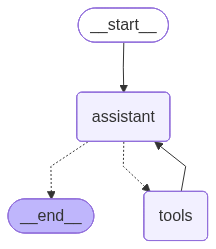

In [ ]:
from IPython.display import Image, display

img = agent.get_graph().draw_mermaid_png()
display(Image(data=img))

## 9. Helper function to run the agent and print the trace

This mirrors your original `query(...)` function, but now the graph handles the loop.

In [9]:
def run_agent(question: str) -> str:
    print(f"Question: {question}\n")

    final_answer = None

    for event in agent.stream(
        {"messages": [HumanMessage(content=question)]},
        stream_mode="values",
    ):
        last_message = event["messages"][-1]

        # Pretty print works in notebooks and terminals.
        last_message.pretty_print()

        if getattr(last_message, "type", None) == "ai" and not getattr(last_message, "tool_calls", None):
            final_answer = last_message.content

    return final_answer

## 10. Test 1: one tool call

This should call `average_dog_weight` once and then answer.

In [10]:
answer = run_agent("How much does a toy poodle weigh?")
answer

Question: How much does a toy poodle weigh?

================================ Human Message =================================

How much does a toy poodle weigh?
================================== Ai Message ==================================
Tool Calls:
  average_dog_weight (call_gHAWKxVj4djOKiTT1zM1TSEi)
 Call ID: call_gHAWKxVj4djOKiTT1zM1TSEi
  Args:
    breed: Toy Poodle
================================= Tool Message =================================
Name: average_dog_weight

a toy poodles average weight is 7 lbs
================================== Ai Message ==================================

A Toy Poodle weighs about 7 pounds on average.


'A Toy Poodle weighs about 7 pounds on average.'

## 11. Test 2: multiple tool calls and a calculation

This is the closest equivalent to the final example in the scratch notebook.

Expected behavior:

1. Look up Border Collie weight.
2. Look up Scottish Terrier weight.
3. Calculate `37 + 20`.
4. Return `57 lbs`.

In [11]:
question = """I have 2 dogs, a border collie and a scottish terrier.
What is their combined weight?"""

answer = run_agent(question)
answer

Question: I have 2 dogs, a border collie and a scottish terrier.
What is their combined weight?

================================ Human Message =================================

I have 2 dogs, a border collie and a scottish terrier.
What is their combined weight?
================================== Ai Message ==================================
Tool Calls:
  average_dog_weight (call_9rxndRVaHyxmaGq9OvQEGcU0)
 Call ID: call_9rxndRVaHyxmaGq9OvQEGcU0
  Args:
    breed: Border Collie
  average_dog_weight (call_Uok518qXCzRPUDZmNbxciZZ0)
 Call ID: call_Uok518qXCzRPUDZmNbxciZZ0
  Args:
    breed: Scottish Terrier
================================= Tool Message =================================
Name: average_dog_weight

Scottish Terriers average 20 lbs
================================== Ai Message ==================================
Tool Calls:
  calculate (call_C9ISl2CFi1WAnG0qYNxJhhsv)
 Call ID: call_C9ISl2CFi1WAnG0qYNxJhhsv
  Args:
    expression: 37 + 20
================================= Tool

'The combined weight of your Border Collie and Scottish Terrier is 57 pounds.'

## 12. Optional: the same idea using LangGraph's prebuilt ReAct agent

The custom graph above is better for teaching because students see the graph structure directly.

For production-like simplicity, LangGraph also provides a prebuilt ReAct agent.  
This hides the graph wiring but keeps the same tool-calling behavior.

In [13]:
# Uncomment to try the prebuilt version.

from langgraph.prebuilt import create_react_agent

prebuilt_agent = create_react_agent(
    model=llm,
    tools=tools,
    prompt=SYSTEM_PROMPT,
)

for event in prebuilt_agent.stream(
    {"messages": [HumanMessage(content=question)]},
    stream_mode="values",
):
    event["messages"][-1].pretty_print()

/tmp/ipykernel_289739/2183231296.py:5: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  prebuilt_agent = create_react_agent(


================================ Human Message =================================

I have 2 dogs, a border collie and a scottish terrier.
What is their combined weight?
================================== Ai Message ==================================
Tool Calls:
  average_dog_weight (call_LT8oAC1wXeP0bAVUKEvmUrw5)
 Call ID: call_LT8oAC1wXeP0bAVUKEvmUrw5
  Args:
    breed: Border Collie
  average_dog_weight (call_wmcuPZGWWVGautQvMn8ENhHY)
 Call ID: call_wmcuPZGWWVGautQvMn8ENhHY
  Args:
    breed: Scottish Terrier
================================= Tool Message =================================
Name: average_dog_weight

Scottish Terriers average 20 lbs
================================== Ai Message ==================================
Tool Calls:
  calculate (call_w01qRj83SiwNbxjxg7WCpCNT)
 Call ID: call_w01qRj83SiwNbxjxg7WCpCNT
  Args:
    expression: 37 + 20
================================= Tool Message =================================
Name: calculate

57
==================================

## 13. Optional free/local model path with Ollama

If you want to avoid paid APIs in a student lab, you can swap the model layer.

Important: use a local model that supports tool calling well. For example:

```bash
ollama pull llama3.1
```

Then replace the OpenAI model cell with:

```python
# %pip install -U langchain-ollama

from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3.1",
    temperature=0,
)

llm_with_tools = llm.bind_tools(tools)
```

The rest of the graph stays the same.

For classroom reliability, the OpenAI path is usually more deterministic; the Ollama path is better when the priority is zero API cost.